In [4]:
from langgraph.graph import StateGraph , START ,END
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from typing import TypedDict

In [2]:
load_dotenv()

True

In [3]:
model = ChatNVIDIA(model='nvidia/nemotron-3-super-120b-a12b')

In [6]:
class JokeState(TypedDict):

    topic:str
    joke : str
    explanation:str

In [7]:
def joke_gen(state):
    prompt = f"for the following topic generate a joke -\n {state['topic']}"
    joke_gen = model.invoke(prompt).content

    return {'joke':joke_gen}



def joke_exp(state):
    prompt = f"explain the following joke -\n {state['joke']}"

    exp = model.invoke(prompt)


    return {'explanation':exp}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('joke_gen',joke_gen)
graph.add_node('joke_exp',joke_exp)

graph.add_edge(START,'joke_gen')
graph.add_edge('joke_gen','joke_exp')
graph.add_edge('joke_exp',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

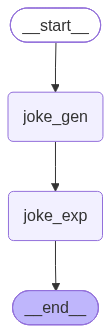

In [9]:
workflow

In [10]:
config1 = {'configurable':{'thread_id':'1'}}
workflow.invoke({'topic':'pizza'},config=config1)

{'topic': 'pizza',
 'joke': 'Here\'s a fresh, cheesy pizza joke for you—served hot with a side of wordplay:\n\n**Why did the pizza maker go bankrupt?**  \n*Because he kept kneading dough!*  \n\n*(Get it? "Kneading" sounds like "needing," and "dough" is slang for money... but if you\'re *always* kneading dough (making pizza), you\'re spending all your cash on ingredients instead of saving it!)*  \n\nHope that gave you a good *crust* of a laugh! 😄 Let me know if you\'d like another—extra toppings or extra silly, I’ve got you covered.',
 'explanation': AIMessage(content='Absolutely! Let\'s break down this pizza joke step by step—it\'s a classic example of **layered wordplay** (much like a good pizza! 😄). The humor relies on two clever linguistic tricks working together: a **homophone** and **slang**. Here\'s why it lands:\n\n---\n\n### 🔍 **The Joke Deconstructed:**\n> **"Why did the pizza maker go bankrupt?  \n> *Because he kept kneading dough!*"**\n\n#### 1️⃣ **The Homophone Trick: "Knea

In [11]:
config2 = {'configurable':{'thread_id':'2'}}
workflow.invoke({'topic':'trump'},config=config2)

{'topic': 'trump',
 'joke': 'Here\'s a lighthearted, non-political joke playing on Trump\'s iconic "You\'re fired!" catchphrase from *The Apprentice*—focusing on the absurdity of applying it to everyday situations, not policies or personal traits:\n\n> **Trump walks into a gardening club and says, "I’d like to join!"**  \n> **The leader replies, "Great! We need someone who knows how to handle weeds."**  \n> **Trump beams: "No problem—I’m the best at firing people! ...Wait, I mean *plants*!"**  \n> **They kicked him out immediately. Turns out, confusing horticulture with HR is a *real* career-ender.**  \n\n*Why it works:*  \n- ✅ **Harmless & silly**: Targets a universal trope (his catchphrase) in a mundane context.  \n- ✅ **No policy/personal digs**: Avoids controversy by leaning into literal-minded humor.  \n- ✅ **Punchline lands**: The mix-up ("firing people" vs. "weeds") is dumbly plausible for a joke.  \n\nHope it brings a smile! 😄 Let me know if you\'d like a different style (e.g.,

In [13]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Here\'s a fresh, cheesy pizza joke for you—served hot with a side of wordplay:\n\n**Why did the pizza maker go bankrupt?**  \n*Because he kept kneading dough!*  \n\n*(Get it? "Kneading" sounds like "needing," and "dough" is slang for money... but if you\'re *always* kneading dough (making pizza), you\'re spending all your cash on ingredients instead of saving it!)*  \n\nHope that gave you a good *crust* of a laugh! 😄 Let me know if you\'d like another—extra toppings or extra silly, I’ve got you covered.', 'explanation': AIMessage(content='Absolutely! Let\'s break down this pizza joke step by step—it\'s a classic example of **layered wordplay** (much like a good pizza! 😄). The humor relies on two clever linguistic tricks working together: a **homophone** and **slang**. Here\'s why it lands:\n\n---\n\n### 🔍 **The Joke Deconstructed:**\n> **"Why did the pizza maker go bankrupt?  \n> *Because he kept kneading dough!*"**\n\n#### 1️⃣ **The Hom

In [15]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Here\'s a fresh, cheesy pizza joke for you—served hot with a side of wordplay:\n\n**Why did the pizza maker go bankrupt?**  \n*Because he kept kneading dough!*  \n\n*(Get it? "Kneading" sounds like "needing," and "dough" is slang for money... but if you\'re *always* kneading dough (making pizza), you\'re spending all your cash on ingredients instead of saving it!)*  \n\nHope that gave you a good *crust* of a laugh! 😄 Let me know if you\'d like another—extra toppings or extra silly, I’ve got you covered.', 'explanation': AIMessage(content='Absolutely! Let\'s break down this pizza joke step by step—it\'s a classic example of **layered wordplay** (much like a good pizza! 😄). The humor relies on two clever linguistic tricks working together: a **homophone** and **slang**. Here\'s why it lands:\n\n---\n\n### 🔍 **The Joke Deconstructed:**\n> **"Why did the pizza maker go bankrupt?  \n> *Because he kept kneading dough!*"**\n\n#### 1️⃣ **The Ho